# YOLO26 Walkthrough 🚀

This notebook is a beginner-friendly, interactive tour of the **YOLO26** object detection model used in `app.py`.

By the end of this notebook you will be able to:

1. Explain what YOLO does and why it's fast enough for real-time video.
2. Describe the three main parts of a YOLO model's architecture (backbone, neck, head).
3. Load the `yolo26n.pt` model and run it on an image.
4. Read and interpret the raw outputs (boxes, classes, confidence scores).
5. Visualize predictions, just like the Streamlit app does.

> No GPU required — the "nano" (`n`) version of YOLO26 used here is small enough to run on a laptop CPU.

## 1. What is YOLO?

**YOLO** stands for **You Only Look Once**. Older detection approaches scanned an image many times, looking at hundreds or thousands of overlapping regions to decide "is there an object here?". That's accurate but slow.

YOLO instead looks at the **entire image in a single forward pass** through a neural network and directly predicts:
- **Where** objects are (bounding boxes)
- **What** they are (class labels, e.g. "person", "dog", "car")
- **How confident** the model is (a score from 0 to 1)

This single-pass design is what makes YOLO fast enough for **real-time** video, like the live webcam feed in `app.py`.

## 2. The Architecture, at a High Level

Every YOLO model (including YOLO26) is built from three stages that data flows through:

```
Image → [ Backbone ] → [ Neck ] → [ Head ] → Boxes + Classes + Scores
```

| Stage | Job | Analogy |
|---|---|---|
| **Backbone** | Extracts features from the raw pixels — edges, textures, shapes — at multiple scales (fine → coarse). | Your eyes noticing shapes and colors before your brain identifies anything. |
| **Neck** | Combines/mixes features from different scales so the model can spot both tiny and huge objects in the same image. | Your brain cross-referencing what your peripheral vision saw with what you're focused on. |
| **Head** | Turns the combined features into final predictions: a bounding box, a class, and a confidence score for each detected object. | Actually saying out loud "that's a dog, over there, and I'm 92% sure." |

### Backbone: turning pixels into features

The backbone is a stack of convolutional blocks that repeatedly downsamples the image (e.g. 640×640 → 320×320 → 160×160 → ... → 20×20), doubling the channel count each time it halves the resolution. The building blocks you'll see in the layer list are:

- **`Conv`**: a convolution + batch norm + activation (SiLU), the basic unit of feature extraction.
- **`C2f` / `C3k2`**: CSP-style blocks — the input is split into two paths, one goes through several small residual bottleneck convs, then both paths are concatenated back together. This lets the network learn rich features while keeping the parameter count low.
- **`SPPF`** (Spatial Pyramid Pooling - Fast): applied near the end of the backbone; repeatedly max-pools the feature map at the same resolution and concatenates the results, cheaply giving each pixel a much larger "receptive field" (awareness of surrounding context).

By the end of the backbone you have several feature maps at different resolutions (e.g. stride 8, 16, 32 — meaning each cell covers an 8×8, 16×16, or 32×32 patch of the original image). Early, high-resolution maps are good at localizing small objects; later, low-resolution maps encode more semantic/abstract information and suit large objects.

### Neck: mixing scales together

The neck takes those multi-resolution feature maps and fuses them, typically shaped like an **FPN + PAN** (Feature Pyramid Network + Path Aggregation Network):

- **Top-down path**: upsample (`Upsample`) coarse, semantically-rich deep features and **`Concat`**enate them with earlier, finer-grained features — this pushes "what is this" understanding down into higher-resolution maps.
- **Bottom-up path**: take that result and downsample it again, concatenating with the deep features once more — this pushes precise "where is this" localization back up into the deep features.
- More `C2f`/`C3k2` blocks after each concatenation to blend the merged features.

The result is a set of feature maps at multiple scales that each carry *both* strong localization and strong classification signal.

### Head: turning features into predictions

The detection head runs on each of the neck's output scales independently and predicts, per grid cell:

- **Box regression branch**: 4 values describing the box (in YOLO26 these are distances to each side of the box, decoded using **DFL**, Distribution Focal Loss, which predicts a small probability distribution over possible distances instead of a single number — this tends to be more accurate than a raw regression).
- **Classification branch**: one probability per class (e.g. "person", "car", ...), each independent (sigmoid) since an object could in principle belong to multiple classes.

Because predictions come from several scales at once, the same object is often predicted multiple times (from neighboring grid cells or adjacent scales). **Non-Max Suppression (NMS)** then discards the overlapping, lower-confidence duplicates and keeps one box per real object.

A few more YOLO-specific details worth knowing:

- **Anchor-free**: newer YOLO versions (including YOLO26) predict box centers and sizes directly, instead of adjusting a fixed set of predefined "anchor box" shapes. This simplifies training and post-processing.
- **Multi-scale detection**: the head produces predictions at several feature-map resolutions so the model can catch small and large objects alike.
- **Non-Max Suppression (NMS)**: the model often proposes several overlapping boxes for the same object. A post-processing step removes duplicates, keeping only the highest-confidence box per object.
- **Model sizes**: YOLO26 ships in sizes like `n` (nano), `s` (small), `m` (medium), `l` (large), `x` (extra-large). Smaller = faster but slightly less accurate. This project uses `yolo26n.pt`, the nano model, so it can run live on CPU.


## 3. Setup

Install dependencies if you haven't already (this repo's `requirements.txt` already includes `ultralytics`).

In [1]:
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

%matplotlib inline

# This CPU doesn't support NNPACK; disable it to silence PyTorch's repeated warning
torch.backends.nnpack.enabled = False

## 4. Load the Model

This loads the exact same `yolo26n.pt` weights file used by `app.py`. The first time it runs, `ultralytics` will parse the file and build the network in memory.

In [2]:
model = YOLO('yolo26n.pt')
print(f'Model loaded: {model.model.__class__.__name__}')
print(f'Number of classes: {len(model.names)}')
print(f'First 10 class names: {list(model.names.values())[:10]}')

Model loaded: DetectionModel
Number of classes: 80
First 10 class names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


### Peek Inside the Network

`model.model` is the actual PyTorch network. Printing it shows the layer-by-layer structure — you'll see the backbone's convolutional layers first, followed by the neck's feature-fusion layers, and finally the detection head at the end.

In [3]:
from collections import Counter

# model.model.model is the ordered list of top-level blocks (backbone -> neck -> head)
blocks = model.model.model
print(f'Total top-level blocks: {len(blocks)}\n')

for i, block in enumerate(blocks):
    print(f'{i:2d}  {block.__class__.__name__}')

# Tally which building-block types show up, and how often
counts = Counter(block.__class__.__name__ for block in blocks)
print('\n--- Block types used ---')
for name, count in counts.most_common():
    print(f'{name:12s} x{count}')


Total top-level blocks: 24

 0  Conv
 1  Conv
 2  C3k2
 3  Conv
 4  C3k2
 5  Conv
 6  C3k2
 7  Conv
 8  C3k2
 9  SPPF
10  C2PSA
11  Upsample
12  Concat
13  C3k2
14  Upsample
15  Concat
16  C3k2
17  Conv
18  Concat
19  C3k2
20  Conv
21  Concat
22  C3k2
23  Detect

--- Block types used ---
C3k2         x8
Conv         x7
Concat       x4
Upsample     x2
SPPF         x1
C2PSA        x1
Detect       x1


## 5. Run Inference on a Sample Image

Let's detect objects in a sample photo. Ultralytics ships a small helper that downloads a well-known test image (a street scene with a bus and pedestrians) so you don't need your own file to try this out.

In [4]:
results = model.predict(source='https://ultralytics.com/images/bus.jpg', verbose=False)
result = results[0]

print(f'Detected {len(result.boxes)} objects')

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Detected 5 objects


[W903 18:43:21.658184444 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.659232437 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.659895837 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.660541331 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.706131090 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.716125793 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.716530774 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.717648135 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.717848518 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


## 6. Understanding the Raw Output

`result.boxes` holds one row per detected object, with:
- `xyxy`: the box corners in pixel coordinates `[x1, y1, x2, y2]`
- `conf`: the confidence score (0–1)
- `cls`: the predicted class id (an index into `model.names`)

This is the same data `app.py` receives every frame from the webcam before drawing boxes on the video.

In [5]:
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(f'{class_name:12s}  confidence={confidence:.2f}  box=({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})')

bus           confidence=0.92  box=(0, 229, 806, 757)
person        confidence=0.91  box=(222, 405, 345, 862)
person        confidence=0.91  box=(48, 399, 239, 903)
person        confidence=0.87  box=(671, 392, 810, 879)
person        confidence=0.53  box=(0, 557, 60, 870)


## 7. Visualize the Detections

`result.plot()` draws the bounding boxes, labels, and confidence scores on the image for you — this is exactly what `app.py` calls on every video frame before streaming it back to the browser.

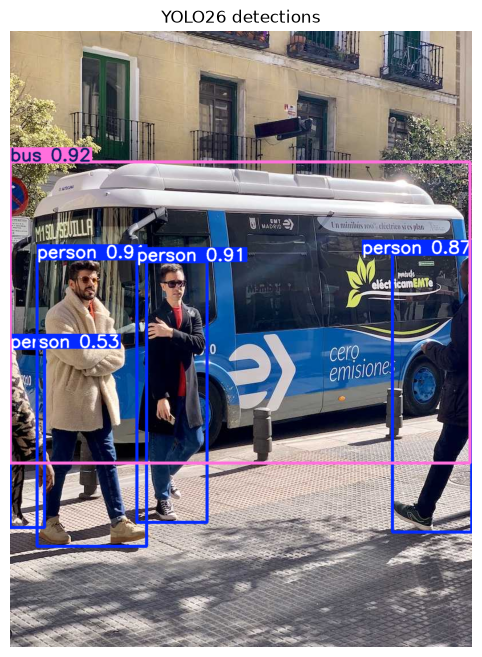

In [6]:
# result.plot() returns a BGR numpy array (OpenCV convention); matplotlib expects RGB
annotated_bgr = result.plot()
annotated_rgb = annotated_bgr[:, :, ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title('YOLO26 detections')
plt.show()

## 8. Try It Yourself

Swap in your own image (a local file path or a URL) and re-run the cells above. Try lowering the `conf` threshold to see more (and less confident) detections, or raising it to see only the model's most confident predictions.

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


[W903 18:43:21.253663420 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.254405014 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.254939670 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.255434920 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.288572894 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.296372315 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.296781623 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.297395535 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W903 18:43:21.297594111 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


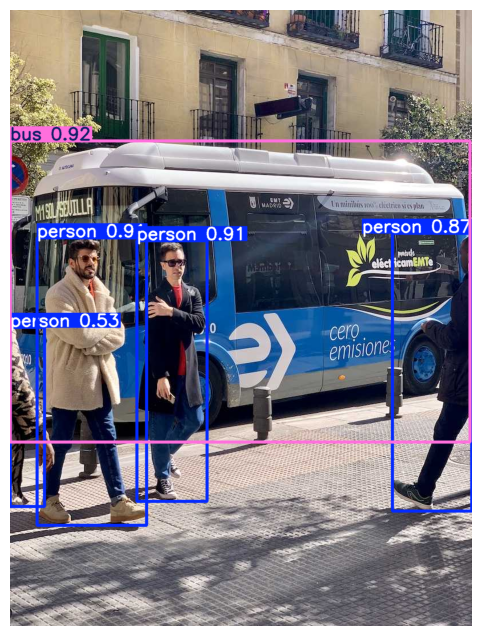

In [7]:
# Try changing the source and confidence threshold, then re-run
my_results = model.predict(source='https://ultralytics.com/images/bus.jpg', conf=0.5, verbose=False)

annotated = my_results[0].plot()[:, :, ::-1]
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis('off')
plt.show()

## 9. From Notebook to Live App

That's really all `app.py` does, just applied to a continuous stream of webcam frames instead of a single image:

1. Load the model once with `@st.cache_resource` (same as our `YOLO('yolo26n.pt')` call).
2. For each incoming video frame, call `model.predict(image)` (same as `model.predict(source=...)` above).
3. Call `results[0].plot()` to draw the boxes (same as our visualization step).
4. Stream the annotated frame back to the browser.

## Recap

- YOLO detects objects in a single forward pass: **backbone** (extract features) → **neck** (fuse multi-scale features) → **head** (predict boxes/classes/scores).
- It's anchor-free and uses Non-Max Suppression to clean up duplicate boxes.
- `yolo26n.pt` is the smallest, fastest variant — ideal for real-time, CPU-only inference.
- The same three lines of code (`load`, `predict`, `plot`) power both this notebook and the live Streamlit app.